In [3]:
from __future__ import print_function

import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import SGD, Adam, Adadelta
from tensorflow.keras.activations import relu
from tensorflow.keras.regularizers import l2
from tensorflow.keras.constraints import max_norm
from tensorflow.keras import backend as K
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

print("Packages Loaded")

Packages Loaded


In [4]:
# Lets import our MNIST data like we did in lab 3.
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [5]:
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()
a = x_train_cifar.reshape(50000, -1)
a.shape

(50000, 3072)

In [6]:
# Now import Cifar-10 data and process it.
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()
x_train_cifar = x_train_cifar.reshape(50000, -1)
x_test_cifar = x_test_cifar.reshape(10000, -1)
x_train_cifar = x_train_cifar.astype('float32') / 255
x_test_cifar = x_test_cifar.astype('float32') / 255

y_test_cifar_origin = y_test_cifar
y_train_cifar = tf.keras.utils.to_categorical(y_train_cifar, 10)
y_test_cifar = tf.keras.utils.to_categorical(y_test_cifar, 10)
input_shape_cifar = x_train_cifar.shape[1:]

In [7]:
%%time
# Our baseline model for this lab.
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(784,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.compile(loss='categorical_crossentropy',
              optimizer=SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True),
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test))

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 4s 68us/step - loss: 0.4140 - acc: 0.8731 - val_loss: 0.1674 - val_acc: 0.9497
Epoch 2/20
60000/60000 [==============================] - 3s 49us/step - loss: 0.1521 - acc: 0.9544 - val_loss: 0.1238 - val_acc: 0.9626
Epoch 3/20
60000/60000 [==============================] - 3s 47us/step - loss: 0.1107 - acc: 0.9662 - val_loss: 0.1071 - val_acc: 0.9655
Epoch 4/20
60000/60000 [==============================] - 3s 45us/step - loss: 0.0876 - acc: 0.9724 - val_loss: 0.1027 - val_acc: 0.9680
Epoch 5/20
60000/60000 [==============================] - 3s 45us/step - loss: 0.0726 - acc: 0.9772 - val_loss: 0.0955 - val_acc: 0.9705
Epoch 6/20
60000/60000 [==============================] - 3s 47us/step - loss: 0.0612 - acc: 0.9807 - val_loss: 0.0902 - val_acc: 0.9731
Epoch 7/20
60000/60000 [==============================] - 3s 48us/step - loss: 0.0531 - acc: 0.9827 - val_loss: 0.0935 - val_acc

### Now convert this baseline into a Functional Model using keras' Functional Model API.
https://keras.io/getting-started/functional-api-guide/

In [8]:
%%time
# Create the functional Baseline here.
inputs = Input(shape=(784,))
output = Dense(64, activation='relu')(inputs)
output = Dense(64, activation='relu')(output)
output = Dense(64, activation='relu')(output)
output = Dense(64, activation='relu')(output)
predictions = Dense(10, activation='softmax')(output)
model = Model(inputs=inputs, outputs=predictions)
model.compile(optimizer=SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True),
              loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test))

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 3s 54us/step - loss: 0.3914 - acc: 0.8826 - val_loss: 0.1861 - val_acc: 0.9440
Epoch 2/20
60000/60000 [==============================] - 3s 46us/step - loss: 0.1473 - acc: 0.9559 - val_loss: 0.1385 - val_acc: 0.9579
Epoch 3/20
60000/60000 [==============================] - 3s 47us/step - loss: 0.1085 - acc: 0.9666 - val_loss: 0.1066 - val_acc: 0.9686
Epoch 4/20
60000/60000 [==============================] - 3s 46us/step - loss: 0.0867 - acc: 0.9730 - val_loss: 0.1007 - val_acc: 0.9696
Epoch 5/20
60000/60000 [==============================] - 3s 46us/step - loss: 0.0733 - acc: 0.9775 - val_loss: 0.1016 - val_acc: 0.9684
Epoch 6/20
60000/60000 [==============================] - 3s 47us/step - loss: 0.0604 - acc: 0.9808 - val_loss: 0.0999 - val_acc: 0.9713
Epoch 7/20
60000/60000 [==============================] - 3s 49us/step - loss: 0.0539 - acc: 0.9831 - val_loss: 0.1176 - val_acc

### Now we are going to compare our baseline to a shallow ResNet that we talked about in class. 
Pay attention to the changes we have made so far including optimizers, batch size, layer neuron width, and dropout.
Why did we make these changes? 

In [133]:
%%time
inputs = tf.keras.Input(shape=(784,), name='img')
x = Dense(128, activation='relu')(inputs)
block_1_output = Dense(128, activation='relu')(x)

x = Dense(128)(block_1_output)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)
x = Dense(128)(x)
x = BatchNormalization()(x)
block_2_output = tf.keras.layers.add([x, block_1_output])

x = Dense(128)(block_2_output)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)
x = Dense(128)(x)
x = BatchNormalization()(x)
block_3_output = tf.keras.layers.add([x, block_2_output])

x = Dense(128)(block_3_output)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)
x = Dense(128)(x)
x = BatchNormalization()(x)
block_4_output = tf.keras.layers.add([x, block_3_output])

x = Dense(128, activation='relu')(block_4_output)
x = Dropout(0.5)(x)
outputs = Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='resnet')

model.compile(Adam(amsgrad=True), 'binary_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train,
          batch_size=128,
          epochs=20,
          validation_data=(x_test, y_test))

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 51s 851us/step - loss: 0.1030 - acc: 0.9658 - val_loss: 0.0326 - val_acc: 0.9889
Epoch 2/20
60000/60000 [==============================] - 10s 173us/step - loss: 0.0369 - acc: 0.9885 - val_loss: 0.0222 - val_acc: 0.9927
Epoch 3/20
60000/60000 [==============================] - 10s 171us/step - loss: 0.0259 - acc: 0.9920 - val_loss: 0.0202 - val_acc: 0.9937
Epoch 4/20
60000/60000 [==============================] - 10s 173us/step - loss: 0.0206 - acc: 0.9936 - val_loss: 0.0175 - val_acc: 0.9946
Epoch 5/20
60000/60000 [==============================] - 10s 175us/step - loss: 0.0170 - acc: 0.9947 - val_loss: 0.0145 - val_acc: 0.9952
Epoch 6/20
60000/60000 [==============================] - 11s 177us/step - loss: 0.0138 - acc: 0.9957 - val_loss: 0.0155 - val_acc: 0.9953
Epoch 7/20
60000/60000 [==============================] - 10s 173us/step - loss: 0.0122 - acc: 0.9962 - val_loss: 0.

In [6]:
plot_model(model, to_file='reports/resnet.png')

### Now lets make a deeper ResNet. Make A network with 10 Residual Blocks. 
How does this affect training speed, accuracy, and stability?

In [7]:
def create_resnet(layers=3, skips=2, input_shape=(784,), neuron=128, lr=1e-3, dropout=0.5, loss='binary_crossentropy'):
    inputs = tf.keras.Input(shape=input_shape, name='img')
    x = Dense(neuron, activation='relu')(inputs)
    block_output = Dense(neuron, activation='relu')(x)
    
    for i in range(layers):
        layer = block_output
        
        
        for idx in range(skips):
            if idx != skips - 1 or skips == 1:
                layer = Dense(neuron)(layer)
                layer = BatchNormalization()(layer)
                layer = Activation('relu')(layer)
                layer = Dropout(dropout)(layer)
            else:                    
                layer = Dense(neuron)(layer)
                layer = BatchNormalization()(layer)
        block_output = tf.keras.layers.add([layer, block_output])
    
    x = Dense(neuron, activation='relu')(block_output)
    x = Dropout(dropout)(x)
    outputs = Dense(10, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs, name='resnet_10')
    optimizer = Adam(amsgrad=True, lr=lr)
    #optimizer = Adadelta(learning_rate=lr)
    model.compile(optimizer, loss, metrics=['accuracy'])
    return model

In [8]:
%%time
# Create the deep ResNet here.
model = create_resnet(layers=10)
model.fit(x_train, y_train, batch_size=128, epochs=20, validation_data=(x_test, y_test))

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 28s 463us/step - loss: 0.1761 - acc: 0.9467 - val_loss: 0.0432 - val_acc: 0.9855
Epoch 2/20
60000/60000 [==============================] - 18s 305us/step - loss: 0.0518 - acc: 0.9839 - val_loss: 0.0283 - val_acc: 0.9907
Epoch 3/20
60000/60000 [==============================] - 17s 289us/step - loss: 0.0354 - acc: 0.9892 - val_loss: 0.0226 - val_acc: 0.9929
Epoch 4/20
60000/60000 [==============================] - 17s 287us/step - loss: 0.0280 - acc: 0.9915 - val_loss: 0.0212 - val_acc: 0.9934
Epoch 5/20
60000/60000 [==============================] - 17s 286us/step - loss: 0.0227 - acc: 0.9931 - val_loss: 0.0198 - val_acc: 0.9940
Epoch 6/20
60000/60000 [==============================] - 17s 288us/step - loss: 0.0192 - acc: 0.9941 - val_loss: 0.0196 - val_acc: 0.9942
Epoch 7/20
60000/60000 [==============================] - 17s 287us/step - loss: 0.0170 - acc: 0.9947 - val_loss: 0.

In [9]:
plot_model(model, to_file='reports/resnet_10.png')

### Now lets mess with the skip connections. We will make two shallow ResNets that have one and three skip connections.

In [8]:
# Here is a one skip connection block.

x = Dense(128)(block_1_output)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)
block_2_output = tf.keras.layers.add([x, block_1_output])

# Here is a two skip connection block.

x = Dense(128)(block_1_output)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)
x = Dense(128)(x)
x = BatchNormalization()(x)
block_2_output = tf.keras.layers.add([x, block_1_output])

# Here is a three skip connection block.

x = Dense(128)(block_1_output)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)
x = Dense(128)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)
x = Dense(128)(x)
x = BatchNormalization()(x)
block_2_output = tf.keras.layers.add([x, block_1_output])


In [13]:
%%time
# Now make a full shallow network with the different sized blocks and compare the models. 
# Resnet with skip 1
resnet_skip1 = create_resnet(layers=3, skips=1)
resnet_skip1.fit(x_train, y_train, batch_size=128, epochs=20, validation_data=(x_test, y_test))

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 9s 153us/step - loss: 0.1146 - acc: 0.9610 - val_loss: 0.0339 - val_acc: 0.9890
Epoch 2/20
60000/60000 [==============================] - 6s 93us/step - loss: 0.0381 - acc: 0.9882 - val_loss: 0.0236 - val_acc: 0.9927
Epoch 3/20
60000/60000 [==============================] - 6s 94us/step - loss: 0.0277 - acc: 0.9915 - val_loss: 0.0209 - val_acc: 0.9937
Epoch 4/20
60000/60000 [==============================] - 6s 95us/step - loss: 0.0216 - acc: 0.9934 - val_loss: 0.0192 - val_acc: 0.9943
Epoch 5/20
60000/60000 [==============================] - 6s 96us/step - loss: 0.0170 - acc: 0.9948 - val_loss: 0.0178 - val_acc: 0.9950
Epoch 6/20
60000/60000 [==============================] - 5s 91us/step - loss: 0.0148 - acc: 0.9954 - val_loss: 0.0164 - val_acc: 0.9951
Epoch 7/20
60000/60000 [==============================] - 5s 87us/step - loss: 0.0132 - acc: 0.9959 - val_loss: 0.0170 - val_ac

In [14]:
plot_model(resnet_skip1, to_file='reports/resnet_skip_1.png')

In [1]:
%%time
# Resnet with skip 3
resnet_skip3 = create_resnet(layers=3, skips=3)
resnet_skip3.fit(x_train, y_train, batch_size=128, epochs=20, validation_data=(x_test, y_test))

NameError: name 'create_resnet' is not defined

In [21]:
plot_model(resnet_skip3, to_file='reports/resnet_skip_3.png')

### Now lets create a Functional Model for CIFAR with the same baseline as MNIST.

In [136]:
%%time
# Create the CIFAR baseline here.
#inputs = Input(shape=(input_shape,))
inputs = Input(shape=input_shape_cifar)
output = Dense(64, activation='relu')(inputs)
output = Dense(64, activation='relu')(output)
output = Dense(64, activation='relu')(output)
output = Dense(64, activation='relu')(output)
predictions = Dense(10, activation='softmax')(output)
model = Model(inputs=inputs, outputs=predictions)
model.compile(optimizer=SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True),
              loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train_cifar, y_train_cifar, epochs=20, batch_size=64, validation_data=(x_test_cifar, y_test_cifar))

Train on 50000 samples, validate on 10000 samples
Epoch 1/20
50000/50000 [==============================] - 50s 1ms/step - loss: 1.8617 - acc: 0.3227 - val_loss: 1.8109 - val_acc: 0.3350
Epoch 2/20
50000/50000 [==============================] - 11s 214us/step - loss: 1.6728 - acc: 0.3976 - val_loss: 1.6225 - val_acc: 0.4075
Epoch 3/20
50000/50000 [==============================] - 11s 214us/step - loss: 1.6014 - acc: 0.4231 - val_loss: 1.6385 - val_acc: 0.4199
Epoch 4/20
50000/50000 [==============================] - 11s 214us/step - loss: 1.5513 - acc: 0.4418 - val_loss: 1.5585 - val_acc: 0.4420
Epoch 5/20
50000/50000 [==============================] - 11s 212us/step - loss: 1.5190 - acc: 0.4544 - val_loss: 1.5248 - val_acc: 0.4519
Epoch 6/20
50000/50000 [==============================] - 11s 214us/step - loss: 1.4880 - acc: 0.4673 - val_loss: 1.5900 - val_acc: 0.4460
Epoch 7/20
50000/50000 [==============================] - 11s 218us/step - loss: 1.4642 - acc: 0.4763 - val_loss: 1.56

### Now lets create a ResNet for CIFAR with the same layers and compare it with MNIST.
Why does our accuracy change so much? 

In [138]:
%%time
# Create the CIFAR ResNet here.
resnet_cifar = create_resnet(input_shape=input_shape_cifar, lr=5e-3)
resnet_cifar.fit(x_train_cifar, y_train_cifar, epochs=20, batch_size=64, validation_data=(x_test_cifar, y_test_cifar))

Train on 50000 samples, validate on 10000 samples
Epoch 1/20
50000/50000 [==============================] - 59s 1ms/step - loss: 0.3247 - acc: 0.8993 - val_loss: 0.3110 - val_acc: 0.9000
Epoch 2/20
50000/50000 [==============================] - 18s 366us/step - loss: 0.3160 - acc: 0.8999 - val_loss: 0.3004 - val_acc: 0.9000
Epoch 3/20
50000/50000 [==============================] - 18s 353us/step - loss: 0.3032 - acc: 0.8995 - val_loss: 0.2937 - val_acc: 0.9000
Epoch 4/20
50000/50000 [==============================] - 18s 359us/step - loss: 0.2909 - acc: 0.8997 - val_loss: 0.2799 - val_acc: 0.8995
Epoch 5/20
50000/50000 [==============================] - 18s 355us/step - loss: 0.2835 - acc: 0.9000 - val_loss: 0.2680 - val_acc: 0.9019
Epoch 6/20
50000/50000 [==============================] - 18s 351us/step - loss: 0.2775 - acc: 0.9007 - val_loss: 0.2612 - val_acc: 0.9026
Epoch 7/20
50000/50000 [==============================] - 18s 367us/step - loss: 0.2712 - acc: 0.9021 - val_loss: 0.26

### Now lets create a custom ResNet.
Change the layer widths, dropout layers, batch sizes, and skip connections to see what we could do to make the ResNet better. Use the knowledge you gained from Lab 3 to do this.

In [106]:
#x_test_cifar = x_test_cifar.reshape(-1, 3, 32, 32)
#x_train_cifar = x_train_cifar.reshape(-1, 3, 32, 32)

In [8]:
# Create your own ResNet here.

def get_dense(neuron):
    result = Dense(neuron)
    return result

def get_conv2d(num_filters=16, kernel_size=1, strides=2, padding='same', kernel_initializer='he_normal'):
    conv = Conv2D(num_filters, kernel_size=kernel_size, strides=2,
                  padding=padding, kernel_initializer=kernel_initializer,
                  #kernel_regularizer=l2(1e-4)
             )
    return conv

def customize_resnet(layers=3, skips=2, lr=1e-3, dropout=0.5, layer_base=get_dense, **kwargs):
    
    input_shape = x_train_cifar.shape[1:]
    inputs = tf.keras.Input(shape=input_shape, name='img')
    #x = Dense(128)(inputs)
    x = layer_base(**kwargs)(inputs)
    x = Activation('relu')(x)
    #block_output = Dense(150)(inputs)
    block_output = layer_base(**kwargs)(x)
    block_output = Activation('relu')(block_output)
    #block_output = x
    #print("block_output:{}".format(block_output.shape))
    
    for i in range(layers):
        layer = block_output
        for idx in range(skips):
            if idx != skips - 1 or skips == 1:
                #layer = Dense(150)(layer)
                layer = layer_base(**kwargs)(layer)
                layer = BatchNormalization()(layer)
                layer = Activation('relu')(layer)
                layer = Dropout(dropout)(layer)
            else:                    
                layer = layer_base(**kwargs)(layer)
                #layer = layer_base(**kwargs)(layer)
                layer = BatchNormalization()(layer)
        #print("layer:{}, block_output:{}".format(layer.shape, block_output.shape))
        block_output = tf.keras.layers.add([layer, block_output])
    
    #x = layer_base(block_output)
    x = layer_base(**kwargs)(block_output)
    x = Activation('relu')(x)
    x = Dropout(dropout)(x)
    #x = Flatten()(x)
    outputs = Dense(10, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs, name='resnet_customized')
    optimizer = Adam(amsgrad=True, lr=lr)
    #optimizer = Adadelta(learning_rate=lr)
    model.compile(optimizer, 'binary_crossentropy', metrics=['accuracy'])
    return model

Train on 50000 samples, validate on 10000 samples
Epoch 1/500
50000/50000 [==============================] - 177s 4ms/step - loss: 0.3177 - acc: 0.8979 - val_loss: 0.2869 - val_acc: 0.9003
Epoch 2/500
50000/50000 [==============================] - 129s 3ms/step - loss: 0.2846 - acc: 0.9004 - val_loss: 0.2761 - val_acc: 0.9021
Epoch 3/500
50000/50000 [==============================] - 134s 3ms/step - loss: 0.2758 - acc: 0.9017 - val_loss: 0.2620 - val_acc: 0.9037
Epoch 4/500
50000/50000 [==============================] - 125s 3ms/step - loss: 0.2697 - acc: 0.9025 - val_loss: 0.2601 - val_acc: 0.9051
Epoch 5/500
50000/50000 [==============================] - 124s 2ms/step - loss: 0.2647 - acc: 0.9033 - val_loss: 0.2567 - val_acc: 0.9046
Epoch 6/500
50000/50000 [==============================] - 132s 3ms/step - loss: 0.2602 - acc: 0.9039 - val_loss: 0.2457 - val_acc: 0.9079
Epoch 7/500
50000/50000 [==============================] - 134s 3ms/step - loss: 0.2552 - acc: 0.9053 - val_loss: 0.

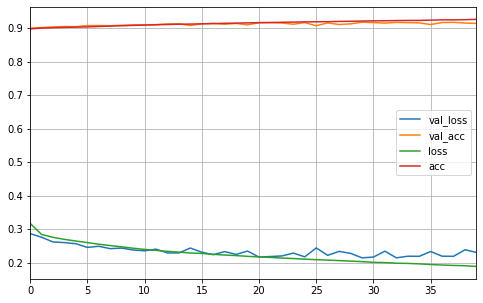

In [9]:
custom_model = customize_resnet(layers=10, skips=5, lr=1e-3, dropout=0.1, neuron=200)
#custom_model = customize_resnet(layers=2, skips=1, lr=1e-3, dropout=0.4, layer_base=get_conv2d,
#                    num_filters=16, kernel_size=1, strides=1, padding='same', kernel_initializer='he_normal')
early_stopping = EarlyStopping(patience=10, monitor='val_acc', mode='max')
best_save = ModelCheckpoint('models/best_cifar.hdf5', save_best_only=True, monitor='val_acc', mode='max')
history = custom_model.fit(x_train_cifar, y_train_cifar, epochs=500, batch_size=32, validation_data=(x_test_cifar, y_test_cifar), callbacks=[early_stopping, best_save])
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 50000 samples, validate on 10000 samples
Epoch 1/500
50000/50000 [==============================] - 428s 9ms/step - loss: 0.2980 - acc: 0.8987 - val_loss: 0.2665 - val_acc: 0.9037
Epoch 2/500
50000/50000 [==============================] - 90s 2ms/step - loss: 0.2633 - acc: 0.9033 - val_loss: 0.2542 - val_acc: 0.9050
Epoch 3/500
50000/50000 [==============================] - 88s 2ms/step - loss: 0.2513 - acc: 0.9059 - val_loss: 0.2453 - val_acc: 0.9068
Epoch 4/500
50000/50000 [==============================] - 87s 2ms/step - loss: 0.2428 - acc: 0.9085 - val_loss: 0.2653 - val_acc: 0.9008
Epoch 5/500
50000/50000 [==============================] - 92s 2ms/step - loss: 0.2360 - acc: 0.9107 - val_loss: 0.2410 - val_acc: 0.9088
Epoch 6/500
50000/50000 [==============================] - 89s 2ms/step - loss: 0.2318 - acc: 0.9119 - val_loss: 0.2849 - val_acc: 0.8985
Epoch 7/500
50000/50000 [==============================] - 90s 2ms/step - loss: 0.2277 - acc: 0.9132 - val_loss: 0.2426 -

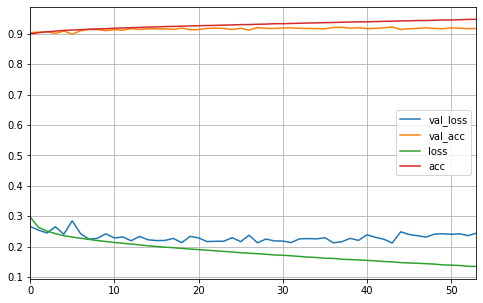

In [158]:
custom_model = customize_resnet(layers=10, skips=3, lr=1e-3, dropout=0.1, neuron=200)
#custom_model = customize_resnet(layers=2, skips=1, lr=1e-3, dropout=0.4, layer_base=get_conv2d,
#                    num_filters=16, kernel_size=1, strides=1, padding='same', kernel_initializer='he_normal')
early_stopping = EarlyStopping(patience=10, monitor='val_acc', mode='max')
best_save = ModelCheckpoint('models/best_cifar_2.hdf5', save_best_only=True, monitor='val_acc', mode='max')
history = custom_model.fit(x_train_cifar, y_train_cifar, epochs=500, batch_size=32, validation_data=(x_test_cifar, y_test_cifar), callbacks=[early_stopping, best_save])
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

In [11]:
plot_model(custom_model, to_file='reports/custom_model.png')